# Predicting irrigation starts

Module B: given a closed valve and recent moisture readings, predict whether the recorded controller opens the valve within 60 minutes.
The labels describe controller behavior. They don't establish whether watering was necessary or optimal.

The workflow is data checks, historical features, a chronological split, model comparison, test evaluation, and export.

## Setup and data

Install dependencies from the repository root:

```powershell
.\.venv\Scripts\python.exe -m pip install -r requirements-notebooks.txt
```

Select the project `.venv` in JupyterLab or VS Code. Training uses CPU.

Source: [Mendeley Data, version 3](https://data.mendeley.com/datasets/cjb4vy4mzj/3),
DOI `10.17632/cjb4vy4mzj.3`, CC BY 4.0. The recordings come from a strawberry field in Paraguay.

The loader downloads `D_moisture.txt` and `D_valve.txt`, both containing CSV data.
If the download fails, get the files from the source page and save them in `data/irrigation/raw/`.
Keep the original files: their hashes are checked against `report/irrigation_dataset_manifest.json`.

In [5]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import sys
import platform

import numpy as np
import pandas as pd
import requests
import joblib
import sklearn
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score,
    precision_score, recall_score, PrecisionRecallDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

print("Python:", platform.python_version())
print("scikit-learn:", sklearn.__version__)
print("Interpreter:", sys.executable)


Python: 3.11.9
scikit-learn: 1.9.1
Interpreter: e:\SIH internal hake\.venv\Scripts\python.exe


In [9]:
# Find the project root from either working directory.
ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "report" / "irrigation_dataset_manifest.json").is_file()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Open this notebook from inside the AGRISMART_AI repository.")

MANIFEST = json.loads((ROOT / "report" / "irrigation_dataset_manifest.json").read_text(encoding="utf-8"))
DATA_DIR = ROOT / "data" / "irrigation" / "raw"
DATA_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
HORIZON = pd.Timedelta("60min")
MAX_VALVE_GAP = pd.Timedelta("10min")
MAX_PREVIOUS_MOISTURE_GAP = pd.Timedelta("40min")
SPLIT_GAP = HORIZON
TRY_DOWNLOAD = True  # Set False if you have already downloaded the files manually.
print("Data directory:", DATA_DIR)


Data directory: e:\SIH internal hake\data\irrigation\raw


## Load the files

Check hashes, columns, timestamps, numeric ranges, and duplicate timestamps.
Repeated moisture values at different times are valid. Only identical timestamp/value pairs are collapsed;
conflicting readings at the same time stop the run.

Timestamps are UTC. Moisture stays on the source sensor's scale and cannot be used as notebook 07's VWC input.

In [11]:
def verified_source_file(spec):
    path = DATA_DIR / spec["name"]
    if not path.exists() and TRY_DOWNLOAD:
        try:
            response = requests.get(spec["url"], timeout=(15, 60))
            response.raise_for_status()
            payload = response.content
            if hashlib.sha256(payload).hexdigest() != spec["sha256"]:
                raise ValueError("Downloaded bytes do not match the published checksum.")
            path.write_bytes(payload)
        except (requests.RequestException, ValueError) as exc:
            print(f"Automatic download unavailable for {spec['name']}: {exc}")
    if not path.is_file():
        raise FileNotFoundError(
            f"Download {spec['name']} from {MANIFEST['source_page']} "
            f"and place it at {path}. Then rerun this cell."
        )
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    if digest != spec["sha256"]:
        raise ValueError(
            f"Checksum mismatch for {path.name}. Download the original version-3 file; "
            "do not silently train on changed or spreadsheet-resaved data."
        )
    return path


def read_sensor_file(spec):
    path = verified_source_file(spec)
    frame = pd.read_csv(path, encoding="utf-8-sig")
    if set(frame.columns) != {spec["column"], "time_stamp"}:
        raise ValueError(f"Unexpected columns in {path.name}: {frame.columns.tolist()}")
    if len(frame) != spec["rows"]:
        raise ValueError(f"Unexpected source row count in {path.name}: {len(frame)}")
    frame["time_stamp"] = pd.to_datetime(
        frame["time_stamp"], format="%d-%b-%Y %H:%M:%S", utc=True, errors="raise"
    )
    frame[spec["column"]] = pd.to_numeric(frame[spec["column"]], errors="raise")
    if frame.isna().any().any() or not np.isfinite(frame[spec["column"]]).all():
        raise ValueError(f"Missing or non-finite data in {path.name}.")
    conflicting = frame.groupby("time_stamp")[spec["column"]].nunique().gt(1)
    if conflicting.any():
        raise ValueError(f"Conflicting same-time readings in {path.name}.")
    return frame.drop_duplicates("time_stamp").sort_values("time_stamp").reset_index(drop=True)


moisture = read_sensor_file(MANIFEST["files"][0])
valve = read_sensor_file(MANIFEST["files"][1])
if not moisture["moisture"].between(0, 100).all():
    raise ValueError("Moisture values are outside the documented percentage scale.")
if not valve["relay"].isin([0, 1]).all():
    raise ValueError("Relay labels must be exactly 0=closed and 1=open.")
valve["relay"] = valve["relay"].astype(int)
display(moisture.head())
display(valve.head())
print("Files verified; no models have been fitted in these loading cells.")


,moisture,time_stamp
0,74.29,2022-07-12 00:03:51+00:00
1,74.29,2022-07-12 00:23:46+00:00
2,74.29,2022-07-12 00:43:41+00:00
3,74.29,2022-07-12 01:03:35+00:00
4,73.88,2022-07-12 01:23:30+00:00


,relay,time_stamp
0,0,2022-07-12 00:00:00+00:00
1,0,2022-07-12 00:05:00+00:00
2,0,2022-07-12 00:10:00+00:00
3,0,2022-07-12 00:15:00+00:00
4,0,2022-07-12 00:20:00+00:00


Files verified; no models have been fitted in these loading cells.


## Check the recordings

Inspect dates and gaps before building features. Raw valve counts differ from the label balance for next-hour openings.
Keep final test outcomes out of feature and threshold selection.

In [12]:
audit = pd.DataFrame([
    {
        "file": name,
        "rows": len(frame),
        "start_utc": frame["time_stamp"].min(),
        "end_utc": frame["time_stamp"].max(),
        "median_gap_minutes": frame["time_stamp"].diff().dt.total_seconds().median() / 60,
        "largest_gap_minutes": frame["time_stamp"].diff().dt.total_seconds().max() / 60,
    }
    for name, frame in [("moisture", moisture), ("valve", valve)]
])
display(audit)
display(valve["relay"].value_counts().rename_axis("raw_relay_state").to_frame("readings"))


,file,rows,start_utc,end_utc,median_gap_minutes,largest_gap_minutes
0,moisture,4293,2022-07-12 00:03:51+00:00,2022-09-16 23:56:08+00:00,19.916667,3783.683333
1,valve,17427,2022-07-12 00:00:00+00:00,2022-09-16 23:57:37+00:00,5.000000,3769.900000


,readings
raw_relay_state,
0,14038
1,3389


## Features and labels

Each moisture timestamp is a possible prediction time. Features use the current and previous moisture readings,
their time gap and rate of change, and trailing three-hour statistics. Future values and cumulative flow are excluded.

Keep a row only when a recent valve reading says the valve is closed.
The target is 1 if an open valve is observed within the next hour, otherwise 0.
Drop incomplete label windows and windows with valve gaps over 10 minutes.

Sampling can miss short openings. Nearby rows may refer to the same opening, so window counts aren't independent event counts.

In [13]:
def build_learning_table(moisture_frame, valve_frame):
    # Use only readings available at prediction time.
    m = moisture_frame.set_index("time_stamp").sort_index().copy()
    gap = m.index.to_series().diff()
    m["sensor_gap_minutes"] = gap.dt.total_seconds() / 60
    previous_is_fresh = gap.le(MAX_PREVIOUS_MOISTURE_GAP) & gap.gt(pd.Timedelta(0))
    m["moisture_lag1"] = m["moisture"].shift(1).where(previous_is_fresh)
    m["moisture_change_per_hour"] = (
        (m["moisture"] - m["moisture_lag1"]) /
        (m["sensor_gap_minutes"] / 60)
    )
    trailing = m["moisture"].rolling("3h", min_periods=3, closed="both")
    m["moisture_mean_3h"] = trailing.mean()
    m["moisture_std_3h"] = trailing.std()
    m["moisture_count_3h"] = m["moisture"].rolling("3h", closed="both").count()
    m = m.reset_index()

    recent_valve = valve_frame.rename(columns={"time_stamp": "valve_observed_at", "relay": "relay_now"})
    joined = pd.merge_asof(
        m.sort_values("time_stamp"), recent_valve.sort_values("valve_observed_at"),
        left_on="time_stamp", right_on="valve_observed_at",
        direction="backward", tolerance=MAX_VALVE_GAP,
    )
    eligible = joined.loc[joined["relay_now"].eq(0)].copy()
    times = pd.DatetimeIndex(valve_frame["time_stamp"])
    states = valve_frame["relay"].to_numpy()
    labels, complete = [], []

    for t in eligible["time_stamp"]:
        end = t + HORIZON
        left = times.searchsorted(t, side="right")
        right = times.searchsorted(end, side="right")
        future_times = times[left:right]
        coverage_ok = end <= times[-1] and len(future_times) > 0
        if coverage_ok:
            coverage_points = pd.DatetimeIndex([t, *future_times, end])
            coverage_ok = (coverage_points[1:] - coverage_points[:-1]).max() <= MAX_VALVE_GAP
        complete.append(bool(coverage_ok))
        labels.append(int(states[left:right].max()) if coverage_ok else np.nan)

    eligible["target"] = labels
    eligible["target_horizon_end"] = eligible["time_stamp"] + HORIZON
    table = eligible.loc[complete].copy()
    table["target"] = table["target"].astype(int)
    counts = {
        "moisture_rows": len(m),
        "fresh_closed_valve_rows": len(eligible),
        "complete_future_windows": len(table),
        "discarded_incomplete_windows": len(eligible) - len(table),
    }
    return table.sort_values("time_stamp").reset_index(drop=True), counts


FEATURES = [
    "moisture", "moisture_lag1", "moisture_change_per_hour",
    "moisture_mean_3h", "moisture_std_3h",
    "moisture_count_3h", "sensor_gap_minutes",
]
learning_table, construction_audit = build_learning_table(moisture, valve)
if learning_table.empty:
    raise ValueError("No usable examples remain. Inspect the source timestamps and gaps.")
print(construction_audit)
assert not {"target", "relay_now", "target_horizon_end", "time_stamp"}.intersection(FEATURES)


{'moisture_rows': 4293, 'fresh_closed_valve_rows': 3458, 'complete_future_windows': 3424, 'discarded_incomplete_windows': 34}


## Chronological split

Use the first 60% of usable time for training, the next 20% for validation, and the last 20% for testing.
Remove label windows that cross a split boundary and leave a one-hour gap before validation and test periods.

Earlier sensor history remains available at later prediction times. Fit imputation and scaling on training rows only.
See [scikit-learn's preprocessing guidance](https://scikit-learn.org/stable/common_pitfalls.html).

In [14]:
start = learning_table["time_stamp"].min()
end = learning_table["time_stamp"].max()
cut_1 = start + (end - start) * 0.60
cut_2 = start + (end - start) * 0.80

train = learning_table.loc[
    (learning_table["time_stamp"] < cut_1) &
    (learning_table["target_horizon_end"] < cut_1)
].copy()
validation = learning_table.loc[
    (learning_table["time_stamp"] >= cut_1 + SPLIT_GAP) &
    (learning_table["time_stamp"] < cut_2) &
    (learning_table["target_horizon_end"] < cut_2)
].copy()
test = learning_table.loc[learning_table["time_stamp"] >= cut_2 + SPLIT_GAP].copy()

for name, part in [("train", train), ("validation", validation), ("test", test)]:
    if len(part) < 50 or set(part["target"]) != {0, 1}:
        raise ValueError(
            f"{name} has insufficient examples or is missing a class. "
            "Inspect coverage; do not replace the temporal holdout with a random split."
        )
assert train["target_horizon_end"].max() < validation["time_stamp"].min()
assert validation["target_horizon_end"].max() < test["time_stamp"].min()

split_summary = pd.DataFrame([
    {"split": name, "rows": len(part),
     "start_utc": part["time_stamp"].min(), "end_utc": part["time_stamp"].max()}
    for name, part in [("train", train), ("validation", validation), ("test", test)]
])
display(split_summary)
# Inspect training labels before model selection.
display(train["target"].value_counts().rename_axis("training_target").to_frame("rows"))

X_train, y_train = train[FEATURES], train["target"]
X_validation, y_validation = validation[FEATURES], validation["target"]
X_test, y_test = test[FEATURES], test["target"]


,split,rows,start_utc,end_utc
0,train,2408,2022-07-12 00:03:51+00:00,2022-08-21 02:58:00+00:00
1,validation,435,2022-08-21 05:17:26+00:00,2022-09-03 05:59:47+00:00
2,test,577,2022-09-07 13:33:33+00:00,2022-09-16 22:56:24+00:00


,rows
training_target,
0,2335
1,73


## Train and compare

Compare four models:

- Majority baseline.
- A decision stump using moisture only.
- Logistic regression with scaling.
- Random forest.

The next cell fits the models. Pipelines contain preprocessing, and non-majority models use class weights.
No synthetic oversampling is used.

In [15]:
def numeric_pipeline(estimator, scale=False):
    steps = [("imputer", SimpleImputer(strategy="median", add_indicator=True, keep_empty_features=True))]
    if scale:
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", estimator))
    return Pipeline(steps)


candidates = {
    "majority": numeric_pipeline(DummyClassifier(strategy="most_frequent")),
    "moisture_stump": Pipeline([
        ("select", ColumnTransformer([("moisture", "passthrough", ["moisture"])], remainder="drop")),
        ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
        ("model", DecisionTreeClassifier(max_depth=1, class_weight="balanced", random_state=SEED)),
    ]),
    "logistic_regression": numeric_pipeline(
        LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED), scale=True
    ),
    "random_forest": numeric_pipeline(
        RandomForestClassifier(
            n_estimators=300, max_depth=10, min_samples_leaf=5,
            class_weight="balanced", random_state=SEED, n_jobs=2,
        )
    ),
}

fitted = {}
for name, candidate in candidates.items():
    fitted[name] = clone(candidate).fit(X_train, y_train)
    print("Trained:", name)


Trained: majority
Trained: moisture_stump
Trained: logistic_regression
Trained: random_forest


## Validation and threshold selection

Try a fixed threshold grid for logistic regression and random forest; baselines use 0.5.
Rank by macro-F1, then positive recall, then proximity to 0.5. A baseline can be selected.

Model scores aren't calibrated probabilities. Report validation results separately from the final test.

In [16]:
def positive_scores(model, X):
    positive_index = list(model.classes_).index(1)
    return model.predict_proba(X)[:, positive_index]


def metric_summary(y, scores, threshold):
    predictions = (scores >= threshold).astype(int)
    return {
        "macro_f1": f1_score(y, predictions, labels=[0, 1], average="macro", zero_division=0),
        "positive_precision": precision_score(y, predictions, zero_division=0),
        "positive_recall": recall_score(y, predictions, zero_division=0),
        "positive_f1": f1_score(y, predictions, zero_division=0),
        "average_precision": average_precision_score(y, scores),
        "accuracy": accuracy_score(y, predictions),
    }


selection_rows = []
for name, model in fitted.items():
    scores = positive_scores(model, X_validation)
    thresholds = [0.5] if name in {"majority", "moisture_stump"} else np.linspace(0.05, 0.95, 19)
    for threshold in thresholds:
        selection_rows.append({
            "model": name, "threshold": float(threshold),
            "distance_from_half": abs(float(threshold) - 0.5),
            **metric_summary(y_validation, scores, threshold),
        })

selection_table = pd.DataFrame(selection_rows).sort_values(
    ["macro_f1", "positive_recall", "distance_from_half", "model"],
    ascending=[False, False, True, True],
)
best_per_model = selection_table.drop_duplicates("model")
display(best_per_model.drop(columns="distance_from_half").reset_index(drop=True))
winner = selection_table.iloc[0]
selected_name = str(winner["model"])
selected_threshold = float(winner["threshold"])
selected_model = fitted[selected_name]
print("Frozen choice:", selected_name, "| threshold:", round(selected_threshold, 3))
if selected_name in {"majority", "moisture_stump"}:
    print("A baseline won validation. Do not claim that a more complex model improved this benchmark.")


,model,threshold,macro_f1,positive_precision,positive_recall,positive_f1,average_precision,accuracy
0,random_forest,0.85,0.760468,0.736842,0.43750,0.549020,0.550435,0.947126
1,logistic_regression,0.80,0.705865,0.368421,0.65625,0.471910,0.451814,0.891954
2,majority,0.50,0.480907,0.000000,0.00000,0.000000,0.073563,0.926437
3,moisture_stump,0.50,0.457752,0.138528,1.00000,0.243346,0.138528,0.542529


Frozen choice: random_forest | threshold: 0.85


## Test results

Evaluate the selected model and threshold on the final period. The majority model and stump are fixed comparisons.
Further tuning against these results would require a new test plan.

The scores describe recorded openings on later dates at the same field. They don't measure crop health or water savings.

Selected model: random_forest


,macro_f1,positive_precision,positive_recall,positive_f1,average_precision,accuracy
0,0.601253,0.277778,0.238095,0.25641,0.363945,0.89948


                             precision    recall  f1-score   support

no observed start within 1h       0.94      0.95      0.95       535
   observed start within 1h       0.28      0.24      0.26        42

                   accuracy                           0.90       577
                  macro avg       0.61      0.59      0.60       577
               weighted avg       0.89      0.90      0.90       577



,model,macro_f1,positive_precision,positive_recall,positive_f1,average_precision,accuracy
0,majority,0.481115,0.000000,0.0,0.000000,0.072790,0.927210
1,moisture_stump,0.468623,0.141892,1.0,0.248521,0.141892,0.559792


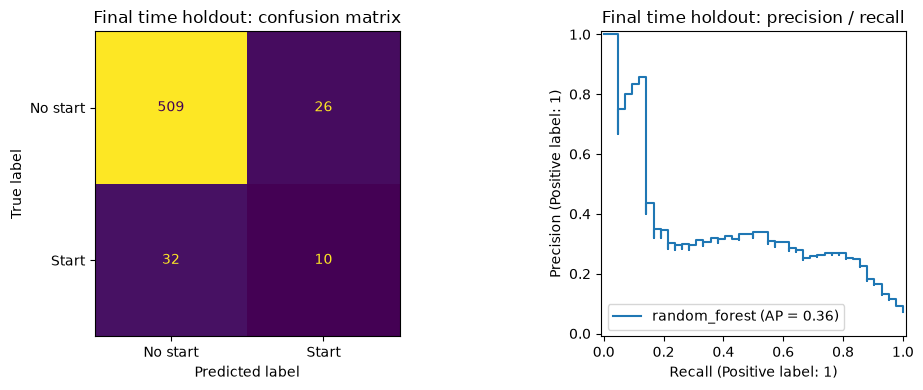

In [17]:
test_scores = positive_scores(selected_model, X_test)
test_predictions = (test_scores >= selected_threshold).astype(int)
test_metrics = metric_summary(y_test, test_scores, selected_threshold)
print("Selected model:", selected_name)
display(pd.DataFrame([test_metrics]))
print(classification_report(
    y_test, test_predictions, labels=[0, 1],
    target_names=["no observed start within 1h", "observed start within 1h"],
    zero_division=0,
))

baseline_results = []
for name in ("majority", "moisture_stump"):
    baseline_results.append({
        "model": name,
        **metric_summary(y_test, positive_scores(fitted[name], X_test), 0.5),
    })
display(pd.DataFrame(baseline_results))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_predictions, labels=[0, 1], display_labels=["No start", "Start"],
    ax=axes[0], colorbar=False,
)
axes[0].set_title("Final time holdout: confusion matrix")
PrecisionRecallDisplay.from_predictions(y_test, test_scores, ax=axes[1], name=selected_name)
axes[1].set_title("Final time holdout: precision / recall")
fig.tight_layout()
plt.show()


## Example prediction

Use a row from the evaluated test period. A positive result means a predicted controller start, not an instruction to switch on a pump.
New inputs need the same sensor scale, historical features, and closed-valve check.

In [18]:
example = X_test.iloc[[0]].copy()
example_score = float(positive_scores(selected_model, example)[0])
display(example)
print({
    "predicted_observed_start_within_1h": bool(example_score >= selected_threshold),
    "uncalibrated_model_score": round(example_score, 4),
    "decision_threshold": selected_threshold,
    "scope": "source field/controller behavior only",
})


,moisture,moisture_lag1,moisture_change_per_hour,moisture_mean_3h,moisture_std_3h,moisture_count_3h,sensor_gap_minutes
2847,69.8,NaN,NaN,NaN,NaN,1.0,3783.683333


{'predicted_observed_start_within_1h': False, 'uncalibrated_model_score': 0.2353, 'decision_threshold': 0.85, 'scope': 'source field/controller behavior only'}


## Save the model

Export the selected pipeline fitted on training rows only, along with its threshold and evaluation report.
Refitting on more data would need a new evaluation plan. Generated files are ignored by Git;
only load joblib files from a trusted source.

In [19]:
MODEL_DIR = ROOT / "model" / "weights" / "irrigation"
METRIC_DIR = ROOT / "outputs" / "metrics"
FIGURE_DIR = ROOT / "outputs" / "figures"
for directory in (MODEL_DIR, METRIC_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

report = {
    "dataset_doi": MANIFEST["doi"],
    "license": MANIFEST["license"],
    "source_files": MANIFEST["files"],
    "target": "observed valve opening in next 60 minutes, conditional on currently closed",
    "features": FEATURES,
    "horizon_minutes": HORIZON.total_seconds() / 60,
    "max_valve_gap_minutes": MAX_VALVE_GAP.total_seconds() / 60,
    "max_previous_moisture_gap_minutes": MAX_PREVIOUS_MOISTURE_GAP.total_seconds() / 60,
    "split_gap_minutes": SPLIT_GAP.total_seconds() / 60,
    "seed": SEED,
    "selected_model": selected_name,
    "decision_threshold": selected_threshold,
    "training_rows": len(train),
    "validation_rows": len(validation),
    "test_rows": len(test),
    "split_boundaries_utc": {"cut_1": str(cut_1), "cut_2": str(cut_2)},
    "construction_audit": construction_audit,
    "test_metrics": {k: float(v) for k, v in test_metrics.items()},
    "confusion_matrix": confusion_matrix(y_test, test_predictions, labels=[0, 1]).tolist(),
    "fixed_baseline_test_metrics": baseline_results,
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "versions": {"python": platform.python_version(), "sklearn": sklearn.__version__,
                 "pandas": pd.__version__, "numpy": np.__version__, "joblib": joblib.__version__},
    "limitations": [
        "One strawberry field and controller; no cross-farm validation.",
        "Observed controller actions are proxy labels, not optimal irrigation ground truth.",
        "Source sensor percentage is not verified VWC and is not portable to arbitrary sensors.",
        "Weather forecasts and crop-stage variation are absent.",
        "Overlapping prediction windows make examples correlated.",
        "No demonstrated water savings, calibrated confidence, or water-quantity prediction.",
    ],
}
bundle = {"pipeline": selected_model, "features": FEATURES,
          "threshold": selected_threshold, "metadata": report}
model_path = MODEL_DIR / "irrigation_start_model.joblib"
joblib.dump(bundle, model_path)
(METRIC_DIR / "irrigation_training_report.json").write_text(
    json.dumps(report, indent=2, default=str), encoding="utf-8"
)
best_per_model.drop(columns="distance_from_half").to_csv(
    METRIC_DIR / "irrigation_validation_comparison.csv", index=False
)
fig.savefig(FIGURE_DIR / "irrigation_test_evaluation.png", dpi=160, bbox_inches="tight")
print("Saved model:", model_path)
print("Saved report:", METRIC_DIR / "irrigation_training_report.json")
print("Model SHA-256:", hashlib.sha256(model_path.read_bytes()).hexdigest())


Saved model: e:\SIH internal hake\model\weights\irrigation\irrigation_start_model.joblib
Saved report: e:\SIH internal hake\outputs\metrics\irrigation_training_report.json
Model SHA-256: 28521c224a66236cdc17775139db3184e78204b78abceb5cc77564572504a98e


## Follow-up

Review the confusion matrix, missed openings, and false alarms. Test another field or season before relying on the model outside this dataset.
Sensor calibration, crop stages, and weather-based advice still need separate work.

References:

- [Mendeley dataset](https://data.mendeley.com/datasets/cjb4vy4mzj/3)
- [Preprocessing and leakage](https://scikit-learn.org/stable/common_pitfalls.html)
- [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)